In [1]:
import torch
print("Number of GPU",torch.cuda.device_count())

print("GPU Name: ",torch.cuda.get_device_name())

Number of GPU 1
GPU Name:  NVIDIA GeForce RTX 2050


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install kagglehub



SyntaxError: invalid syntax (115542665.py, line 1)

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

c:\Users\raiar\.conda\envs\test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\raiar\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1


In [6]:
import os

print(os.listdir(path))

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [7]:
for item in os.listdir(path):
    item_path = os.path.join(path, item)

    if os.path.isdir(item_path):
        print(f"\n{item}/")
        print(os.listdir(item_path)[:10])


Meta/
['.~lock.ClassesInformation.ods#', '.~lock.ClassesInformationStrong.ods#', '0.png', '1.png', '10.png', '11.png', '12.png', '13.png', '14.png', '15.png']

Test/
['00000.png', '00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png']

Train/
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']


In [8]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = os.path.join(path, "Train")

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

print("Number of classes:", len(train_dataset.classes))
print("Total training images:", len(train_dataset))

Number of classes: 43
Total training images: 39209


In [9]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


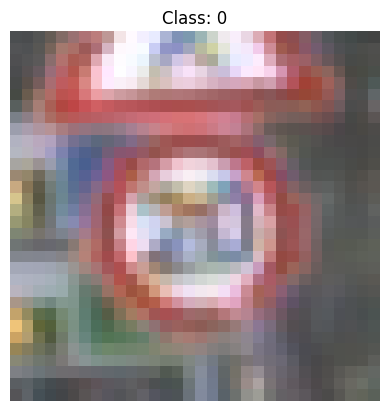

In [10]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image.permute(1,2,0))
plt.title(f"Class: {label}")
plt.axis("off")
plt.show()

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
# 64 = no of images, 3 = RGB, 32 = height, 32 = width

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [12]:
import torch
import torch.nn as nn

class TrafficSignCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 43)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TrafficSignCNN().to(device)

print(model)

TrafficSignCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, in

In [14]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([64, 43])


In [15]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [16]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch [1/10], Loss: 0.7111
Epoch [2/10], Loss: 0.0900
Epoch [3/10], Loss: 0.0491
Epoch [4/10], Loss: 0.0389
Epoch [5/10], Loss: 0.0346
Epoch [6/10], Loss: 0.0282
Epoch [7/10], Loss: 0.0256
Epoch [8/10], Loss: 0.0264
Epoch [9/10], Loss: 0.0219
Epoch [10/10], Loss: 0.0178


In [17]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [18]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")



Validation Accuracy: 99.95%


In [19]:
torch.save(model.state_dict(), "traffic_sign_cnn.pth")

In [20]:
class_names = train_dataset.dataset.classes
print(class_names)

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [22]:
pip install pandas


  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 5.6 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/11.3 MB 3.5 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/11.3 MB 3.1 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.3 MB 2.9 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.3 MB 2.9 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.3 MB 2.9 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/11.3 MB 1.7 MB/s eta 0:00:06
   --------- ------------------------------ 2.6/11.3 MB 1.5 MB/s eta 0:00:06
   --------- ------------------------------ 2.6/11.3 MB 1.5 MB/s eta 0:00:06
   ----------- ---------------------------- 3.1/11.3 MB 1.5 MB/s eta 0:00:06
   ------------ --------------------------- 3.4/11.3 MB 1.5 MB/s eta 0:00:06
   -----------

In [23]:
import pandas as pd
import os

test_csv = os.path.join(path, "Test.csv")

df = pd.read_csv(test_csv)

print(df.head())
print(df.columns)

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png
Index(['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId',
       'Path'],
      dtype='object')


In [35]:
class_to_idx = train_dataset.dataset.class_to_idx

print(class_to_idx)

{'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, '41': 36, '42': 37, '5': 38, '6': 39, '7': 40, '8': 41, '9': 42}


In [36]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os

class GTSRBTestDataset(Dataset):

    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.root_dir,
            self.data.iloc[idx]["Path"]
        )

        image = Image.open(img_path).convert("RGB")

        label = int(self.data.iloc[idx]["ClassId"])
        label = class_to_idx[str(label)]

        if self.transform:
            image = self.transform(image)

        return image, label

In [37]:
test_csv = os.path.join(path, "Test.csv")

test_dataset = GTSRBTestDataset(
    csv_file=test_csv,
    root_dir=path,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Test Images:", len(test_dataset))

Test Images: 12630


In [38]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Official Test Accuracy: {test_accuracy:.2f}%")

Official Test Accuracy: 97.28%


In [40]:
torch.save(model.state_dict(), "traffic_sign_cnn.pth")

In [41]:
import json

with open("class_mapping.json", "w") as f:
    json.dump(class_to_idx, f)